## Breast Cancer Classification using SVM

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

## Data Overview and EDA

In [3]:
print("Dataset Shape:", df.shape)
print("\nFeature Names:")
print(data.feature_names.tolist())
print("\nTarget Names:", data.target_names.tolist())
print("\nClass Distribution:")
print(df['target'].value_counts())

Dataset Shape: (569, 31)

Feature Names:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

Target Names: ['malignant', 'benign']

Class Distribution:
target
1    357
0    212
Name: count, dtype: int64


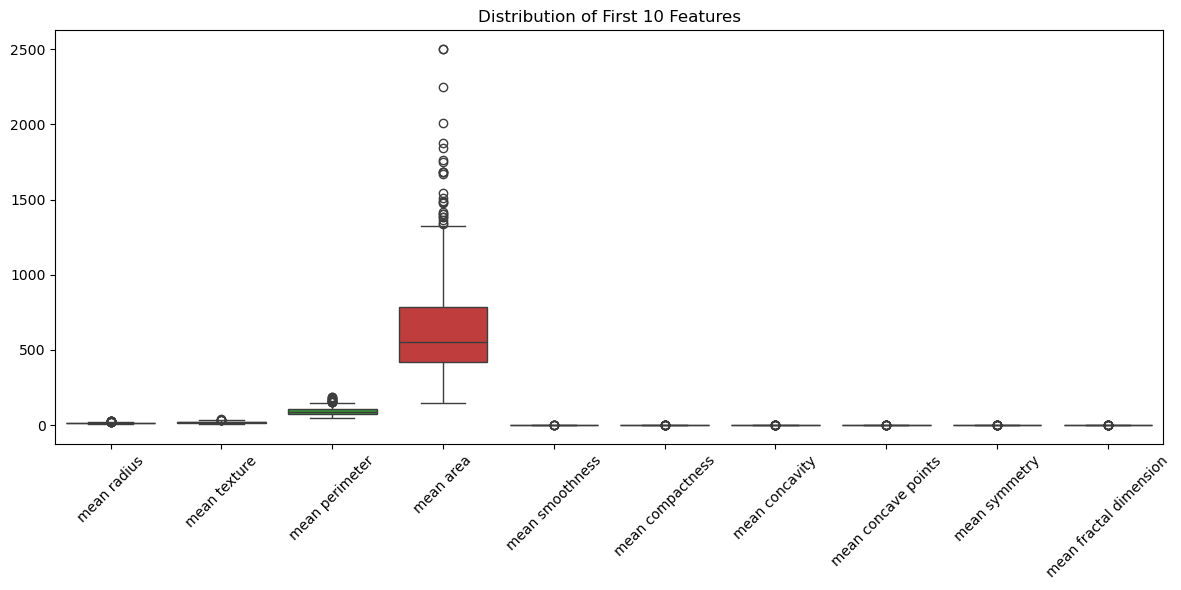

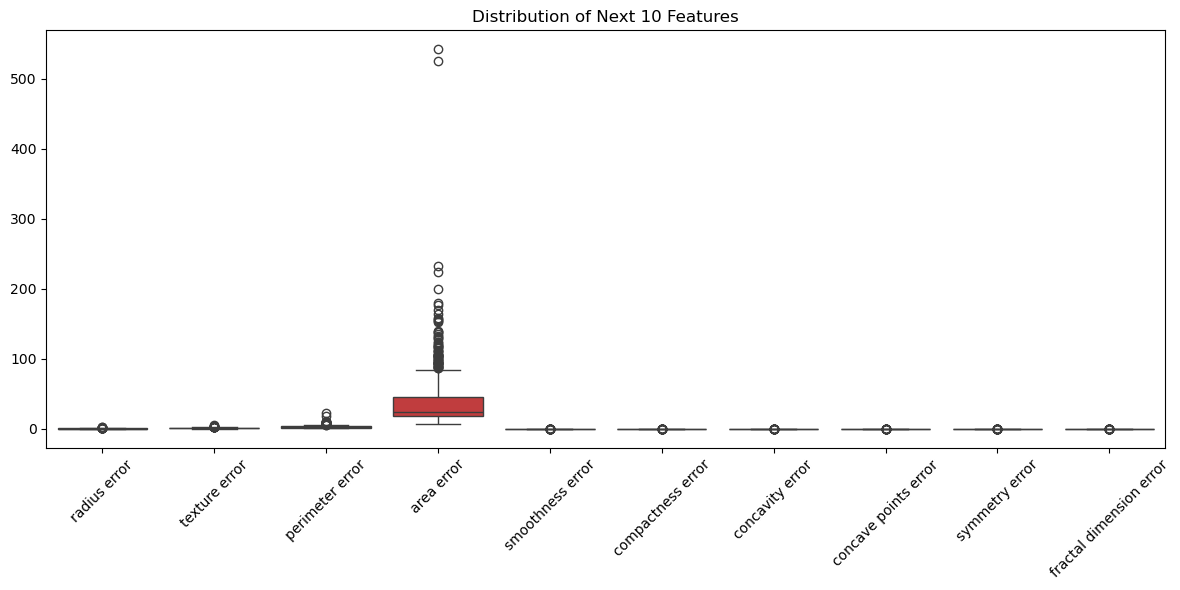

In [4]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.iloc[:, :10])
plt.xticks(rotation=45)
plt.title('Distribution of First 10 Features')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df.iloc[:, 10:20])
plt.xticks(rotation=45)
plt.title('Distribution of Next 10 Features')
plt.tight_layout()
plt.show()

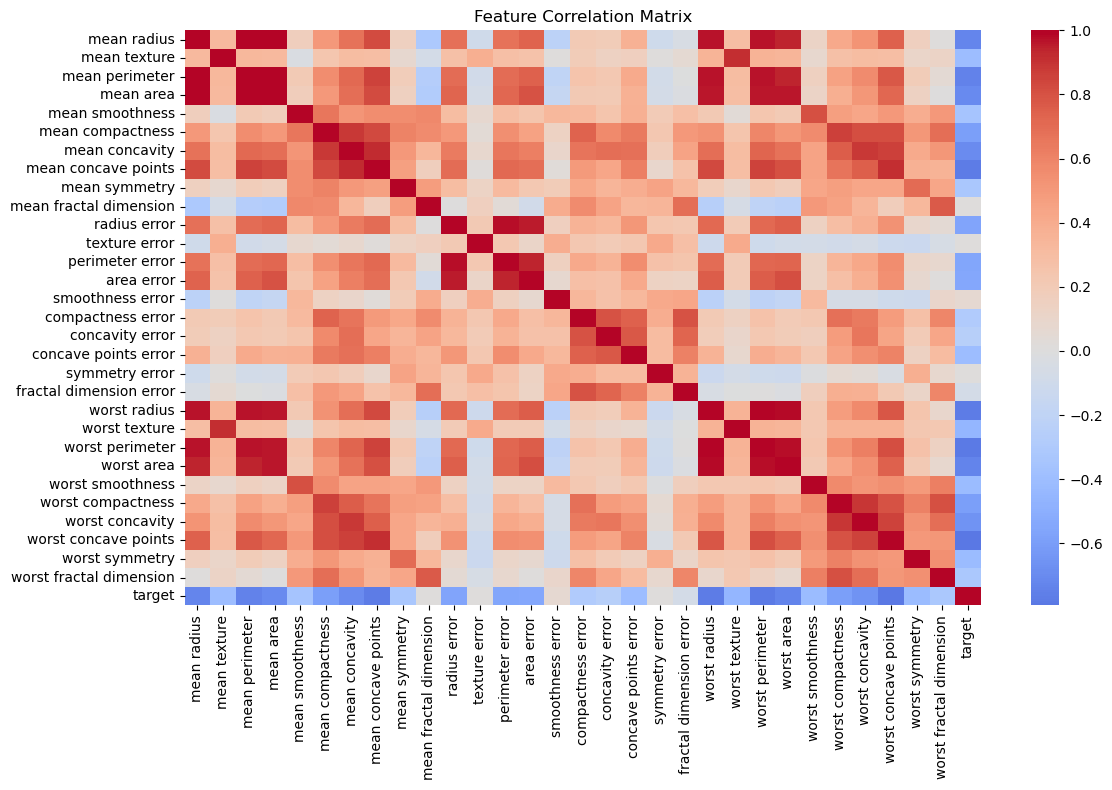

In [5]:
correlation_matrix = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## Data Preprocessing

In [6]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Training and Evaluation

In [7]:
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)

predictions = svm_model.predict(X_test_scaled)

print("Model Performance Metrics:")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Model Performance Metrics:

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



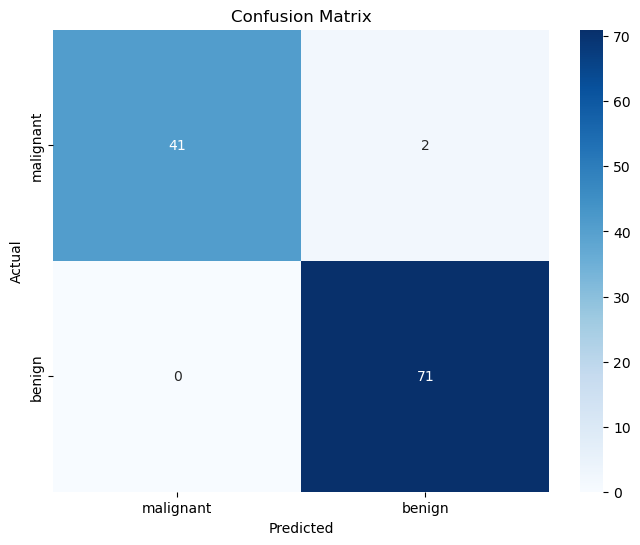

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, predictions), 
            annot=True, 
            fmt='d',
            cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Model Optimization

In [9]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'kernel': ['rbf', 'linear']
}

grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5)
grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross-Validation Score: 0.9758241758241759


Optimized Model Performance:

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



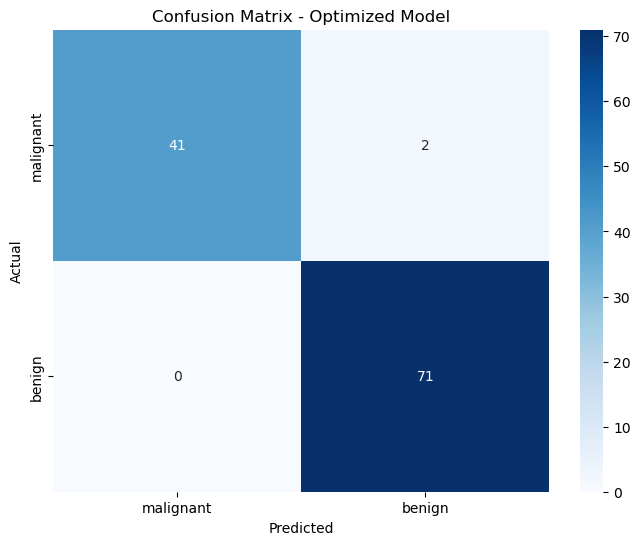

In [10]:
optimized_model = grid_search.best_estimator_
optimized_predictions = optimized_model.predict(X_test_scaled)

print("Optimized Model Performance:")
print("\nClassification Report:")
print(classification_report(y_test, optimized_predictions))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, optimized_predictions),
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.title('Confusion Matrix - Optimized Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()